1. Hệ số trong  RNN là gì :
Trong CNN, hệ số chính là các trọng số (weights) của kernel/filter dùng trong phép tích chập (convolution).
 * Các hệ số giúp kernel:

- phát hiện cạnh
- phát hiện đường ngang/dọc
- phát hiện texture
- trích xuất đặc trưng ảnh.
* Ban đầu:
- hệ số được khởi tạo ngẫu nhiên.
Trong quá trình train:
- CNN dùng backpropagation
- cập nhật hệ số liên tục
- để giảm loss.
* Sau khi học:
- các hệ số sẽ chứa thông tin đặc trưng quan trọng của ảnh.

Cài đặt 

In [1]:
!pip install torch torchvision torchaudio

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import transforms
import torchvision

import matplotlib.pyplot as plt

from collections import namedtuple

from sklearn.metrics import classification_report

Code CNN CIFAR10

In [7]:
def get_clases():
  classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
  return classes

TrainTest = namedtuple('TrainTest', ['train', 'test'])

def prepare_data():
  # tham khảo thêm https://github.com/albumentations-team/albumentations
  transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
  ])
  transform_test = transforms.Compose([
    transforms.ToTensor()
  ])
  trainset = torchvision.datasets.CIFAR10(root='./data', download=True, train=True, transform=transform_train)
  testset = torchvision.datasets.CIFAR10(root='./data', download=True, train=False, transform=transform_test)
  return TrainTest(train=trainset, test=testset)

def prepare_loader(datasets):
  trainloader = DataLoader(dataset=datasets.train, batch_size=128, shuffle=True, num_workers=4)
  testloader = DataLoader(dataset=datasets.test, batch_size=128, shuffle=False, num_workers=4)
  return TrainTest(train=trainloader, test=testloader)

class VGG16(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = self._make_features()
    self.classification_head = nn.Linear(in_features=512, out_features=10)

  def forward(self, x):
    out = self.features(x)
    out = out.view(out.size(0), -1)
    out = self.classification_head(out)
    return out

  def _make_features(self):
    config = [64,64,'MP',128,128,'MP',256,256,256,'MP',512,512,512,'MP',512,512,512,'MP']
    layers = []
    c_in = 3
    for c in config:
      if c == 'MP':
        layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
      else:
        layers += [nn.Conv2d(in_channels=c_in, out_channels=c, kernel_size=3, stride=1, padding=1),
                   nn.BatchNorm2d(num_features=c),
                   nn.ReLU6(inplace=True)]
        c_in = c
    return nn.Sequential(*layers)

def imshow(images, labels, predicted, target_names):
  img = torchvision.utils.make_grid(images)
  plt.imshow(img.permute(1,2,0).cpu().numpy())
  [print(target_names[c], end=' ') for c in list(labels.cpu().numpy()) ]
  print()
  [print(target_names[c], end=' ') for c in list(predicted.cpu().numpy()) ]
  print()

def train_epoch(epoch, model, loader, loss_func, optimizer, device):
  model.train()
  running_loss = 0.0
  reporting_steps = 60
  for i, (images, labels) in enumerate(loader):
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    loss = loss_func(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if i % reporting_steps == reporting_steps-1:
      print(f"Epoch {epoch} step {i} ave_loss {running_loss/reporting_steps:.4f}")
      running_loss = 0.0

def test_epoch(epoch, model, loader, device):
  ytrue = []
  ypred = []
  with torch.no_grad():
    model.eval()
    
    for i, (images, labels) in enumerate(loader):
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs, dim=1)

      ytrue += list(labels.cpu().numpy())
      ypred += list(predicted.cpu().numpy())

  return ypred, ytrue

def main(PATH='./model.pth'):
  classes = get_clases()
  datasets = prepare_data()
  # img, label = datasets.train[0]
  # plt.imshow(img)
  # print(classes[label], img.size)
  # print('train', len(datasets.train), 'test', len(datasets.test))
  
  loaders = prepare_loader(datasets)
  # images, labels = iter(loaders.train).next()
  # print(images.shape, labels.shape)

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = VGG16().to(device)
  # images, labels = iter(loaders.train).next()
  # outputs = model(images)
  # print(outputs.shape)
  # print(outputs[0])
  # _, predicted = torch.max(outputs, dim=1)
  # print(predicted)
  # imshow(images, labels, predicted, classes)

  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
  for epoch in range(10):
    train_epoch(epoch, model, loaders.train, loss_func, optimizer, device)
    ypred, ytrue = test_epoch(epoch, model, loaders.test, device)
    print(classification_report(ytrue, ypred, target_names=classes))

    torch.save(model.state_dict(), PATH)

  return model

model = main()

KeyboardInterrupt: 

RNN dự báo giá bitcoin


In [5]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.19.1-cp313-cp313-win_amd64.whl.metadata (32 kB)
Using cached tensorflow-2.21.

c:\Users\ACER\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 758s 4ms/step - loss: 5.5518e-07 - val_loss: 7.4157e-06
Epoch 2/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 1096s 6ms/step - loss: 9.2948e-08 - val_loss: 2.3306e-05
Epoch 3/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 711s 4ms/step - loss: 8.7264e-08 - val_loss: 1.2347e-05
Epoch 4/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 683s 4ms/step - loss: 6.6009e-08 - val_loss: 4.2455e-05
Epoch 5/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 720s 4ms/step - loss: 6.4907e-08 - val_loss: 3.7987e-05
Epoch 6/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 689s 4ms/step - loss: 5.9734e-08 - val_loss: 5.4654e-05
Epoch 7/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 696s 4ms/step - loss: 5.8309e-08 - val_loss: 8.1652e-05
Epoch 8/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 665s 4ms/step - loss: 6.1457e-08 - val_loss: 4.6293e-05
Epoch 9/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 673s 4ms/step - loss: 6.4500e-08 - val_loss: 1.2308e-04
Epoch 10/20
189064/189064 ━━━━━━━━━━━━━━━━━━━━ 635s 3ms/step - loss: 7.5695e-08 -

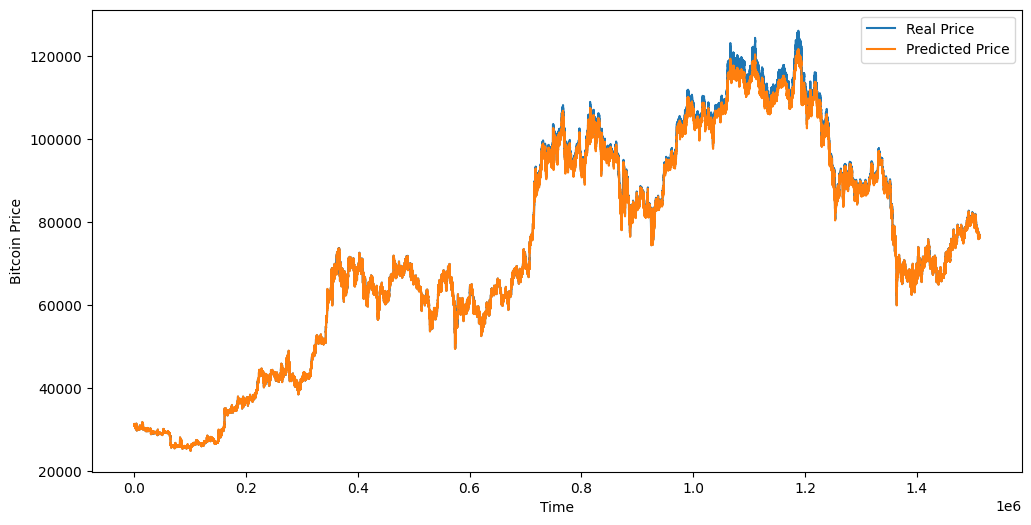

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# Đọc dữ liệu
df = pd.read_csv("btcusd_1-min_data.csv")

# Chỉ lấy giá đóng cửa
data = df['Close'].values.reshape(-1,1)

# Chuẩn hóa
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Tạo chuỗi dữ liệu
X = []
y = []

time_step = 30

for i in range(time_step, len(data_scaled)):
    X.append(data_scaled[i-time_step:i, 0])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape cho RNN
X = X.reshape((X.shape[0], X.shape[1], 1))

# Chia train/test
split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

# Xây dựng mô hình RNN
model = Sequential()

model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(X_train.shape[1], 1)
))

model.add(Dense(1))

# Compile
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Predict
predicted = model.predict(X_test)

# Chuyển về giá trị gốc
predicted = scaler.inverse_transform(predicted.reshape(-1,1))
real = scaler.inverse_transform(y_test.reshape(-1,1))

# Vẽ kết quả
plt.figure(figsize=(12,6))

plt.plot(real, label='Real Price')
plt.plot(predicted, label='Predicted Price')

plt.xlabel("Time")
plt.ylabel("Bitcoin Price")
plt.legend()

plt.show()